# Breast Cancer Classification using Support Vector Machines (SVM)

## Introduction

Support Vector Machine (SVM) is one of the most effective supervised machine learning algorithms for classification tasks, especially when dealing with high-dimensional data. In this project, SVM is applied to classify breast cancer tumors as either benign or malignant. Different kernel functions are explored, including Linear, RBF, and Polynomial kernels, to compare their performance. Hyperparameter tuning, performance analysis, and experiments on noisy and overlapping data are also performed to better understand the strengths and limitations of SVM.

## Project Objectives

The main objectives of this project are:

Build an SVM classifier for breast cancer classification.
Compare the performance of Linear, RBF, and Polynomial kernels.
Perform feature selection and data visualization.
Tune hyperparameters using Grid Search.
Measure training and prediction times under different scenarios.
Analyze the impact of noisy and overlapping data on SVM performance.

Classes: The dataset has two target classes:
Malignant (denoted by 0)
Benign (denoted by 1)

- radius_mean: Mean of distances from the center to points on the perimeter.
- texture_mean: Standard deviation of gray-scale values.
- perimeter_mean: Mean of perimeter values.
- area_mean: Mean of area values.
- smoothness_mean: Mean of local variation in radius lengths.
- compactness_mean: Mean of perimeter^2 / area - 1.0
- concavity_mean: Mean of severity of concave portions of the contour.
- concave points_mean: Mean for the number of concave portions of the contour.
- symmetry_mean: Mean of symmetry.
- fractal_dimension_mean: Mean of the "coastline approximation" - 1.
- radius_se: Standard error for radius.
- texture_se: Standard error for texture.
- perimeter_se: Standard error for perimeter.
- area_se: Standard error for area.
- smoothness_se: Standard error for smoothness.
- compactness_se: Standard error for compactness.
- concavity_se: Standard error for concavity.
- concave points_se: Standard error for concave points.
- symmetry_se: Standard error for symmetry.
- fractal_dimension_se: Standard error for fractal dimension.
- radius_worst: Worst or largest radius value.
- texture_worst: Worst texture value.
- perimeter_worst: Worst perimeter value.
- area_worst: Worst area value.
- smoothness_worst: Worst smoothness value.
- compactness_worst: Worst compactness value.
- concavity_worst: Worst concavity value.
- concave points_worst: Worst concave points value.
- symmetry_worst: Worst symmetry value.
- fractal_dimension_worst: Worst fractal dimension value.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC , SVR
from sklearn.metrics import accuracy_score
# from file_name import fun_name
from svm_margin_plot import plot_svm_boundary
import time

In [55]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Assign the correct column names based on the dataset documentation
columns = ['ID', 'Diagnosis'] + [
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean',
    'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se',
    'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst',
    'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst',
    'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Load the dataset and assign these column names
data = pd.read_csv(url, header=None, names=columns)
data.drop(columns=['ID'], inplace=True)


In [56]:
data.head()

,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [57]:
data.Diagnosis.value_counts()

Diagnosis
B    357
M    212
Name: count, dtype: int64

In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

In [59]:
data.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [60]:
data.isna().sum()

Diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [62]:
data.duplicated().sum()

0

In [63]:
data.nunique()

Diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: int64

In [64]:
data.Diagnosis

0      M
1      M
2      M
3      M
4      M
      ..
564    M
565    M
566    M
567    M
568    B
Name: Diagnosis, Length: 569, dtype: object

In [65]:
le = LabelEncoder()
data['Diagnosis'] = le.fit_transform(data['Diagnosis'])

In [66]:
data.Diagnosis

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: Diagnosis, Length: 569, dtype: int32

Two features from dataset to apply SVM and Logistic Regression
algorithms for classification: 
radius_mean
texture_mean

### why?
We selected radius_mean and texture_mean because they are highly informative and complementary features for classification. radius_mean is strongly correlated with the target label and provides clear class separation, while texture_mean captures additional variation in the data related to surface structure. Together, they form a meaningful 2D feature space that improves class visualization and helps evaluate the performance of SVM and Logistic Regression effectively.

### Scatter Plot:

<function matplotlib.pyplot.show(close=None, block=None)>

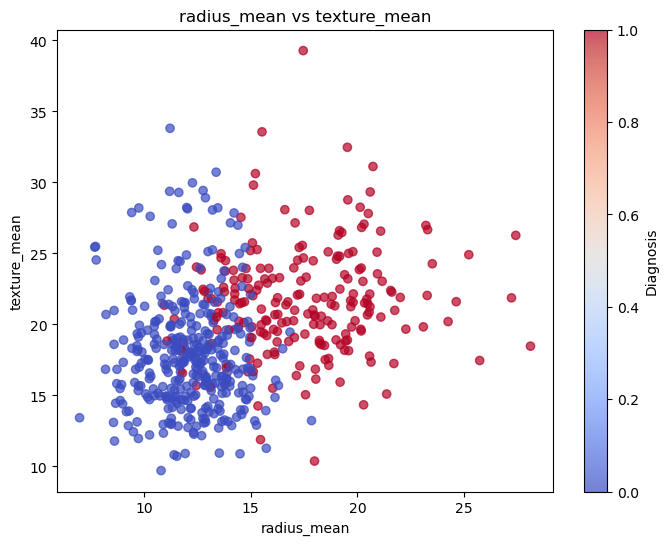

In [67]:
x=data[['radius_mean','texture_mean']]
y=data['Diagnosis']
plt.figure(figsize=(8,6))
plt.scatter(x['radius_mean'],x['texture_mean'],c=y,cmap='coolwarm',alpha=0.7)
plt.xlabel('radius_mean')
plt.ylabel('texture_mean')
plt.title('radius_mean vs texture_mean')
plt.colorbar(label='Diagnosis')
plt.show

#### explaination:
The scatter plot shows a partial separation between benign and malignant classes. Malignant tumors tend to have higher values of both radius_mean and texture_mean, while benign tumors are concentrated in lower ranges. However, there is noticeable overlap between the two classes, indicating that the data is not perfectly linearly separable. This suggests that non-linear models such as SVM with RBF kernel may perform better than linear models.

In [68]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [69]:
log_model = LogisticRegression()
log_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [70]:
svm_model = SVC(kernel='linear')
svm_model.fit(x_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [71]:
y_pred_log = log_model.predict(x_test)
y_pred_svm = svm_model.predict(x_test)

In [72]:
log_acc = accuracy_score(y_test,y_pred_log)
svm_acc = accuracy_score(y_test,y_pred_svm)
print("Logistic regression accuracy:",log_acc)
print("SVM accuracy:",svm_acc)

Logistic regression accuracy: 0.9122807017543859
SVM accuracy: 0.9035087719298246


## Shuffle & Split

In [73]:
data= data.sample(frac=1,random_state=42).reset_index(drop=True)

In [74]:
x=data[['radius_mean','texture_mean']]
y =data['Diagnosis']

x_train= x.iloc[:400]
y_train= y.iloc[:400]
x_val =x.iloc[400:500]
y_val =y.iloc[400:500]
x_test =x.iloc[500:]
y_test =y.iloc[500:]

## Preprocessing

In [75]:
scaler= StandardScaler()
x_train_scaled= scaler.fit_transform(x_train)
x_val_scaled= scaler.transform(x_val)
x_test_scaled= scaler.transform(x_test)


In [76]:
data.dtypes


Diagnosis                    int32
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst            float64
concave points_worst

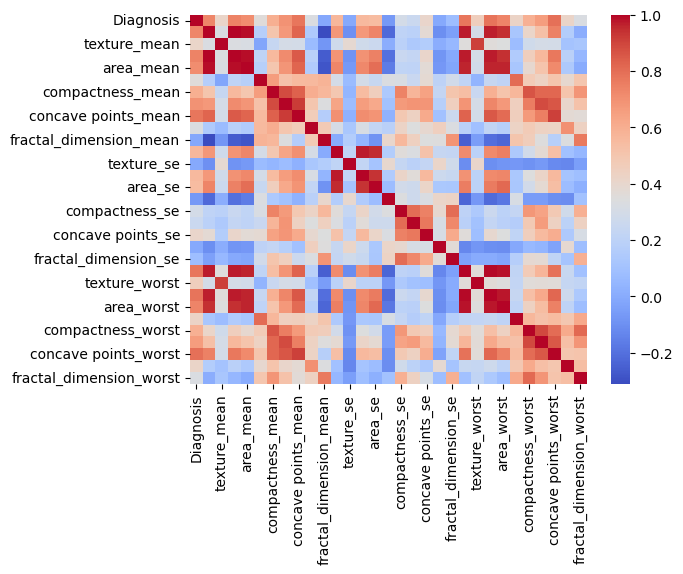

In [77]:
corr=data.corr(numeric_only=True)
plt.Figure(figsize=(12,8 ))
sns.heatmap(corr,cmap='coolwarm')
plt.show()

In [78]:
corr = data.corr(numeric_only=True)

corr['Diagnosis'].sort_values(ascending=False)


Diagnosis                  1.000000
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
symmetry_se               -0

In [79]:
x_2d=data[['radius_mean','concave points_mean']]
y=data['Diagnosis']

<function matplotlib.pyplot.show(close=None, block=None)>

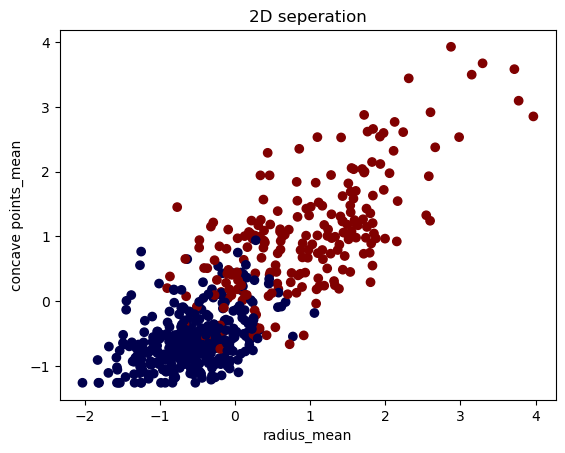

In [80]:
scaler = StandardScaler()
x_2d_scaled=scaler.fit_transform(x_2d)

plt.scatter(x_2d_scaled[:,0],x_2d_scaled[:,1],c=y,cmap='seismic')
plt.xlabel('radius_mean')
plt.ylabel('concave points_mean')
plt.title('2D seperation')
plt.show

## SVM Classifiers Training

### Linear Krenel and Decision Boundary:

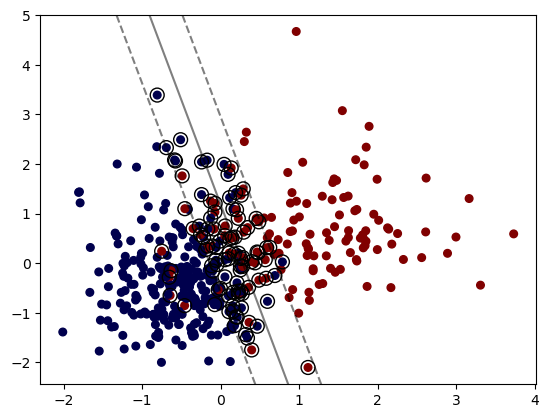

In [81]:
linear_svm=SVC(kernel='linear', C=1)
linear_svm.fit(x_train_scaled,y_train)
plot_svm_boundary(linear_svm,x_train_scaled,y_train)

#### Explain the results:
The dataset is not perfectly linearly separable, but it has a relatively clear separation between the two classes. Some points overlap between the classes, which makes perfect linear separation impossible.

SVM handles this by finding the optimal hyperplane that maximizes the margin between the classes instead of trying to perfectly separate all points. It also relies on support vectors, which are the most important points near the boundary, to define the decision boundary. In cases where data is not fully separable, SVM allows some misclassification while still maintaining a large margin.

### RBF Kernel and Decision Boundary:

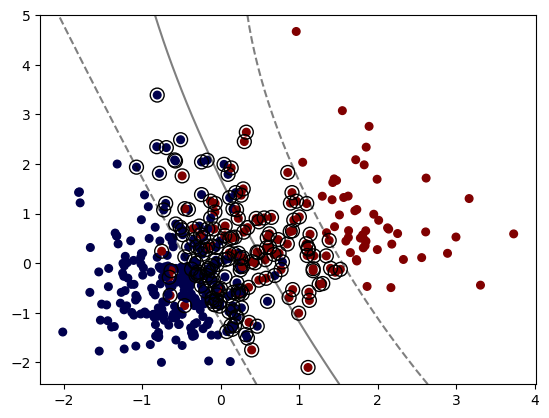

In [82]:
rbf_svm = SVC(kernel='rbf', C=1,gamma=0.01)
rbf_svm.fit(x_train_scaled,y_train)
plot_svm_boundary(rbf_svm,x_train_scaled,y_train)


#### Compare the results with the linear kernel:
The linear kernel creates a straight decision boundary, which works well when the data is approximately linearly separable. However, the dataset still contains overlapping points between the two classes, so the linear boundary cannot perfectly capture the complex separation.

The RBF (Radial Basis Function) kernel produces a more flexible and non-linear decision boundary compared to the linear kernel. This allows the classifier to better adapt to the shape of the data and separate overlapping regions more effectively.

The polynomial (poly) kernel also creates a non-linear boundary, but it does so using polynomial curves. Compared to the linear kernel, it can capture more complex relationships between features. In this case, the poly kernel provides a more flexible boundary than the linear kernel, although it may become sensitive to noise or overfitting depending on the polynomial degree.

SVM with the RBF kernel uses the kernel trick to implicitly map the original data into a higher-dimensional feature space without explicitly computing the transformation. In this higher-dimensional space, data that is not linearly separable in the original 2D space can become separable using a linear hyperplane. This is why the RBF kernel is often more powerful for handling complex datasets with non-linear patterns.

### poly Kernel and Decision Boundary:

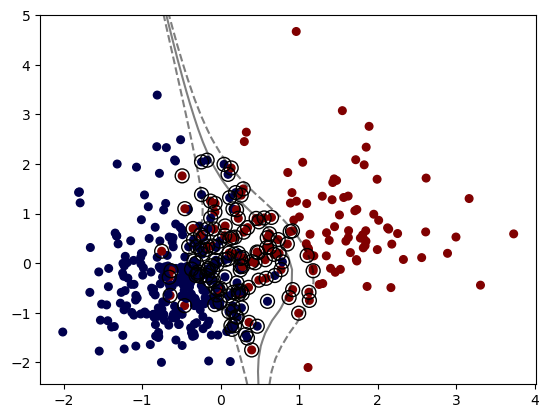

In [83]:
poly_svm = SVC(kernel='poly',C=1,degree=3)
poly_svm.fit(x_train_scaled,y_train)
plot_svm_boundary(poly_svm,x_train_scaled,y_train)

#### Compare the results with the linear kernel:
The linear kernel creates a single straight decision boundary, which works well when the classes are approximately linearly separable. However, in this dataset, the two classes overlap around the center, so a straight line cannot perfectly separate them. As a result, some samples are misclassified.

The polynomial (poly) kernel creates a curved decision boundary that better follows the shape of the data. This allows the classifier to capture more complex relationships between the features and classify samples more accurately in regions where the classes are not linearly separable.

Unlike the linear kernel, the poly kernel implicitly maps the data into a higher-dimensional feature space using the kernel trick. Instead of explicitly computing the transformed features, it computes polynomial similarities between samples. In this higher-dimensional space, the classes become easier to separate with a linear hyperplane, which appears as a curved boundary when projected back to the original two-dimensional space.

## Compare kernels accuracy scores

In [84]:
kernels =['linear','rbf','poly']
results={}
for k in kernels:
    model= SVC(kernel=k)
    model.fit(x_train_scaled,y_train)
    y_val_pred= model.predict(x_val_scaled)
    y_test_pred= model.predict(x_test_scaled)
    val_acc = accuracy_score(y_val,y_val_pred)
    test_acc = accuracy_score(y_test,y_test_pred)
    results[k]=(val_acc,test_acc)
print(results)

{'linear': (0.83, 0.8695652173913043), 'rbf': (0.88, 0.8695652173913043), 'poly': (0.77, 0.8260869565217391)}


##  Grid search for hyperparameters tunning

In [85]:
model = SVC(kernel='rbf')

parameters ={
    'C' : [0.01,0.1,1,10,100],
    'gamma':[0.001,0.01,0.1,1],
    'degree':[2 , 3  , 4 , 5 , 6]
    }

grid = GridSearchCV(model , parameters)
grid.fit(x_train_scaled,y_train)
print("Best Parameters:", grid.best_estimator_)
print("Best accuracy score:", grid.best_score_)

Best Parameters: SVC(C=10, degree=2, gamma=0.1)
Best accuracy score: 0.9174999999999999


In [86]:
best_model = SVC(C=10, degree=2, gamma=0.1,kernel='rbf')
best_model.fit(x_train_scaled , y_train)
y_val_pred=best_model.predict(x_val_scaled)
y_test_pred=best_model.predict(x_test_scaled)
print("validation accuracy: ",accuracy_score(y_val,y_val_pred))
print("test accuracy:",accuracy_score(y_test,y_test_pred))

validation accuracy:  0.87
test accuracy: 0.855072463768116


In [87]:
results = pd.DataFrame(grid.cv_results_)
print(results[['param_C','param_gamma','mean_test_score']])

    param_C  param_gamma  mean_test_score
0      0.01        0.001           0.6475
1      0.01        0.010           0.6475
2      0.01        0.100           0.6475
3      0.01        1.000           0.6475
4      0.01        0.001           0.6475
..      ...          ...              ...
95   100.00        1.000           0.8975
96   100.00        0.001           0.9000
97   100.00        0.010           0.9075
98   100.00        0.100           0.9150
99   100.00        1.000           0.8975

[100 rows x 3 columns]


In [88]:
c_scores=(results.groupby('param_C')['mean_test_score'].max())
gamma_scores=(results.groupby('param_gamma')['mean_test_score'].max())

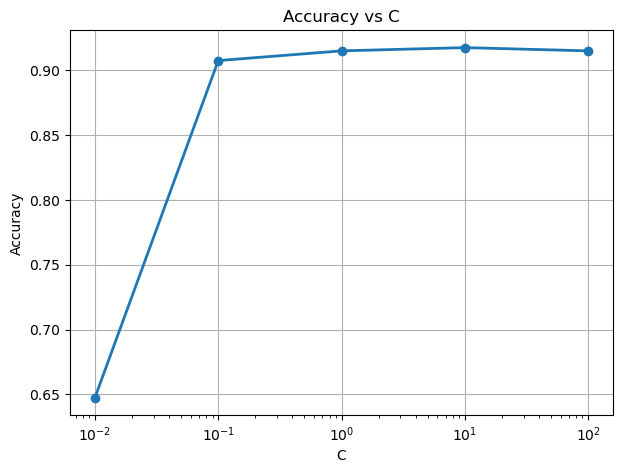

In [89]:
plt.figure(figsize=(7,5))
plt.plot(c_scores.index.astype(float), c_scores.values, marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('C')
plt.ylabel("Accuracy")
plt.title('Accuracy vs C')
plt.grid(True)
plt.show()

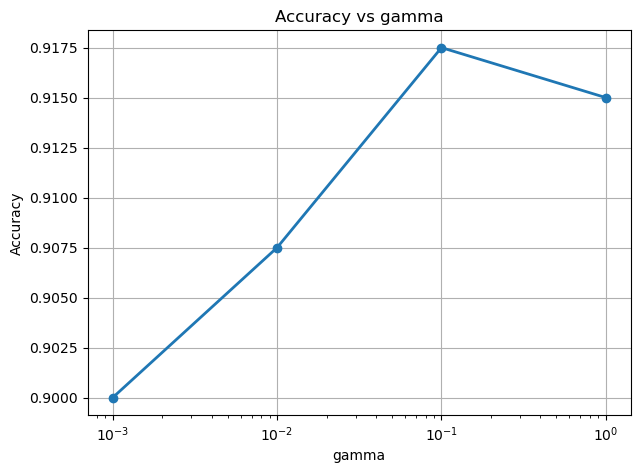

In [90]:
plt.figure(figsize=(7,5))
plt.plot(gamma_scores.index.astype(float), gamma_scores.values, marker='o', linewidth=2)
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel("Accuracy")
plt.title('Accuracy vs gamma')
plt.grid(True)
plt.show()

## Performance Analysis

In [91]:
n = int(0.10 * len(x_train_scaled))
x_train_10=x_train_scaled[:n]
y_train_10= y_train[:n]
results=[]
cases=[{'name':'Linear (10%)', 'kernel':'linear','c':1 ,'gamma':'scale','x_train':x_train_10, 'y_train':y_train_10},
        {'name':'Linear (100%)', 'kernel':'linear','c':1 ,'gamma':'scale','x_train':x_train, 'y_train':y_train},
        {'name':'rbf (10%)', 'kernel':'rbf','c':1 ,'gamma':0.01,'x_train':x_train_10, 'y_train':y_train_10},
        {'name':'rbf (100%)', 'kernel':'rbf','c':1 ,'gamma':0.01,'x_train':x_train, 'y_train':y_train}
]
for case in cases:
    model=SVC(kernel=case["kernel"], C=case['c'], gamma=case['gamma'])
    start= time.perf_counter()
    model.fit(case['x_train'], case['y_train'])
    train_time= time.perf_counter() - start

    start= time.perf_counter()
    model.predict(x_test)
    pred_time= time.perf_counter() - start

    results.append({'scenario':case['name'],'Training Time (s)': train_time, "Predection Time (s)":pred_time})
    results_df=pd.DataFrame(results)
    display(results_df)

C:\Users\Legion 7i\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


,scenario,Training Time (s),Predection Time (s)
0,Linear (10%),0.001023,0.001068


,scenario,Training Time (s),Predection Time (s)
0,Linear (10%),0.001023,0.001068
1,Linear (100%),0.003068,0.000915


C:\Users\Legion 7i\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


,scenario,Training Time (s),Predection Time (s)
0,Linear (10%),0.001023,0.001068
1,Linear (100%),0.003068,0.000915
2,rbf (10%),0.000710,0.000985


,scenario,Training Time (s),Predection Time (s)
0,Linear (10%),0.001023,0.001068
1,Linear (100%),0.003068,0.000915
2,rbf (10%),0.000710,0.000985
3,rbf (100%),0.002395,0.001098


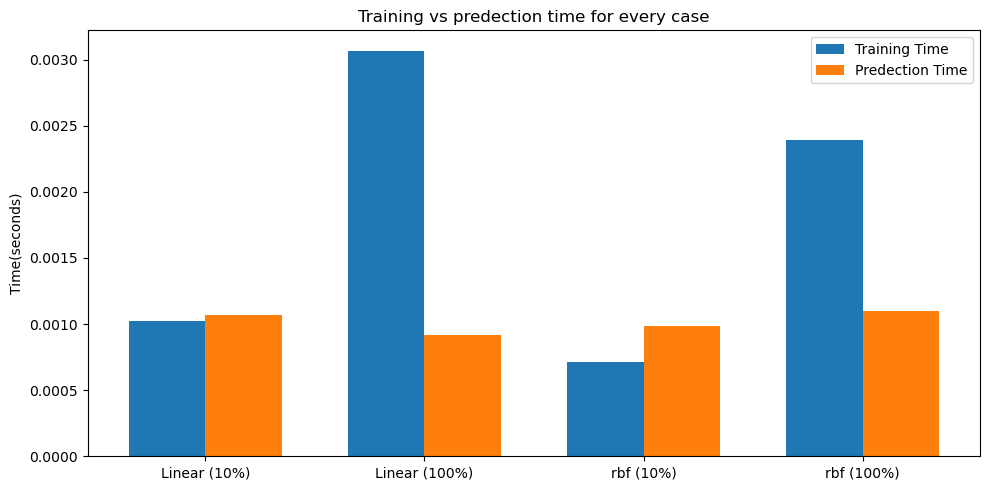

In [92]:
plt.figure(figsize=(10,5))
x= range(len(results_df))
width= 0.35
plt.bar([i-width/2 for i in x],results_df['Training Time (s)'],width=width,label="Training Time")
plt.bar([i+width/2 for i in x],results_df['Predection Time (s)'],width=width,label="Predection Time")
plt.xticks(x, results_df['scenario'])
plt.ylabel('Time(seconds)')
plt.title("Training vs predection time for every case")
plt.legend()
plt.tight_layout()
plt.show()

## Overlapping Classes

In [93]:
x_overlap=x_train_scaled.copy()
for feature in range(x_overlap.shape[1]):
    feature_mean=x_overlap[:,feature].mean()
    x_overlap[:,feature]=(0.5*x_overlap[:,feature]+0.5*feature_mean)

best_C=best_model.C
best_gamma=best_model.gamma

svm_overlap= SVC(kernel='rbf',C=best_C, gamma=best_gamma,random_state=42)
svm_overlap.fit(x_overlap,y_train)

val_pred_overlap=svm_overlap.predict(x_val_scaled)
test_pred_overlap=svm_overlap.predict(x_test_scaled)

val_acc_overlap= accuracy_score(y_val,val_pred_overlap)
test_acc_overlap= accuracy_score(y_test,test_pred_overlap)

print(f"Accuracy : {val_acc_overlap:.4f}")
print(f"Testing Accuracy : {test_acc_overlap:.4f}")

Accuracy : 0.8500
Testing Accuracy : 0.8841


After creating overlapping classes, the validation and testing accuracies decreased compared with the clean dataset. This happened because the two classes became less separable, making it difficult for the SVM classifier to find an optimal decision boundary. As more samples lie close to or across the decision boundary, the number of classification errors increases, resulting in lower accuracy

## Noisy Data

In [94]:
x_noise = x_train_scaled.copy()
np.random.seed(42)
num_samples=int(0.10*len(x_noise))
indices=np.random.choice(len(x_noise),size=num_samples,replace=False)

noise=np.random.normal(loc=0,scale=0.2,size=(num_samples,x_noise.shape[1]))

x_noise[indices]+-noise
svm_noise=SVC(kernel='rbf',C=best_C,gamma=best_gamma,random_state=42)
svm_noise.fit(x_noise,y_train)

val_pred_noise=svm_noise.predict(x_val_scaled)
test_pred_noise=svm_noise.predict(x_test_scaled)

val_acc_noise= accuracy_score(y_val,val_pred_noise)
test_acc_noise= accuracy_score(y_test,test_pred_noise)

print(f"Accuracy : {val_acc_noise:.4f}")
print(f"Testing Accuracy : {test_acc_noise:.4f}")

Accuracy : 0.8700
Testing Accuracy : 0.8551


After adding Gaussian noise to 10% of the training samples, the validation and testing accuracies also decreased. The added noise distorted the feature values, making some training samples less representative of their true class. Consequently, the SVM model learned a less accurate decision boundary, leading to reduced performance on unseen data

### compare with clean data

In [95]:
clean_val_acc= accuracy_score(y_val,best_model.predict(x_val_scaled))
clean_test_acc= accuracy_score(y_test,best_model.predict(x_test_scaled))
comparison=pd.DataFrame({'Dataset':['Clean','overlapping','Noisy'],
                         'Validation Accuracy':[clean_val_acc,val_acc_overlap,val_acc_noise],
                         'Testing Accuracy':[clean_test_acc,test_acc_overlap,test_acc_noise]})
comparison

,Dataset,Validation Accuracy,Testing Accuracy
0,Clean,0.87,0.855072
1,overlapping,0.85,0.884058
2,Noisy,0.87,0.855072


The clean dataset provided stable classification performance. Creating overlapping classes slightly reduced the validation accuracy, showing that overlapping makes it more difficult for SVM to learn an optimal decision boundary. On the other hand, adding Gaussian noise to only 10% of the training samples did not noticeably affect the model's performance in this experiment, indicating that the tuned RBF SVM was relatively robust to this level of noise

## Conclusion

### SVM's strengths:
Performs well on high-dimensional datasets.
Achieves high accuracy when classes are well separated.
Can model non-linear decision boundaries effectively using kernels such as RBF.
Hyperparameter tuning using Grid Search can further improve performance

### SVM's weaknesses:
Performance decreases when classes become less separable.
Can be affected by noisy or overlapping data, depending on the amount of noise.
Training time increases as the size of the training dataset grows.
Requires careful tuning of parameters such as C and gamma to obtain the best results.